Saving marketing_campaign.xlsx to marketing_campaign (1).xlsx
Dataset Loaded Successfully

Dataset Shape:
(2240, 29)

First 5 Records:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94    

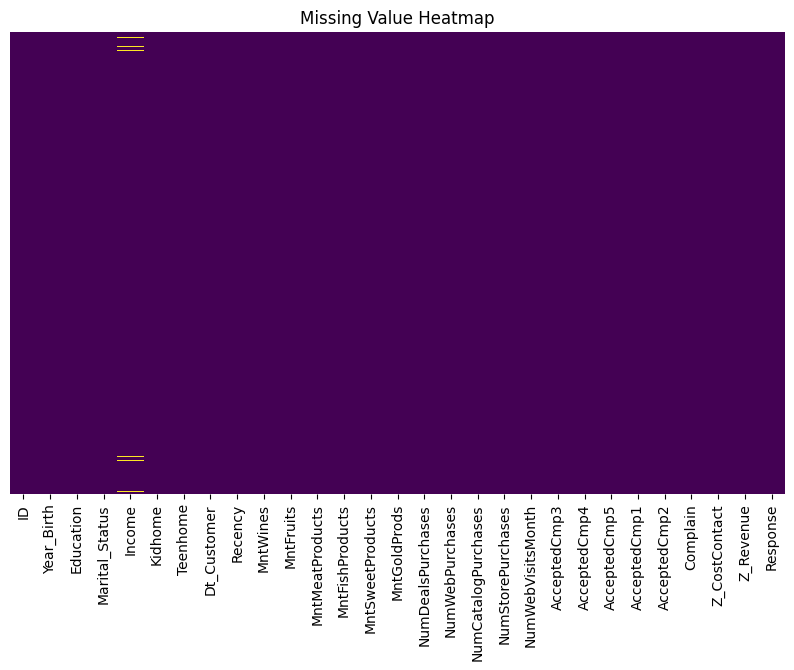


Missing Values Before Treatment:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Missing Values After Treatment:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome        

In [1]:
# ==========================================================
# STEP 1: IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files


# ==========================================================
# STEP 2: UPLOAD DATASET
# ==========================================================

uploaded = files.upload()

# Automatically read uploaded Excel file

file_name = list(uploaded.keys())[0]

df = pd.read_excel('/content/marketing_campaign.xlsx')


# ==========================================================
# STEP 3: DISPLAY BASIC INFORMATION
# ==========================================================

print("Dataset Loaded Successfully")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


# ==========================================================
# STEP 4: CHECK MISSING VALUES
# ==========================================================

print("\nMissing Values:")
print(df.isnull().sum())

plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)

plt.title(
    "Missing Value Heatmap"
)

plt.show()


# ==========================================================
# STEP 5: HANDLE MISSING VALUES
# ==========================================================

print("\nMissing Values Before Treatment:")

print(df.isnull().sum())

df["Income"] = df["Income"].fillna(
    df["Income"].median()
)

print("\nMissing Values After Treatment:")

print(df.isnull().sum())


Number of Duplicate Records: 0

Dataset Shape After Removing Duplicates:
(2240, 29)

Response Variable Distribution:
Response
0    1906
1     334
Name: count, dtype: int64


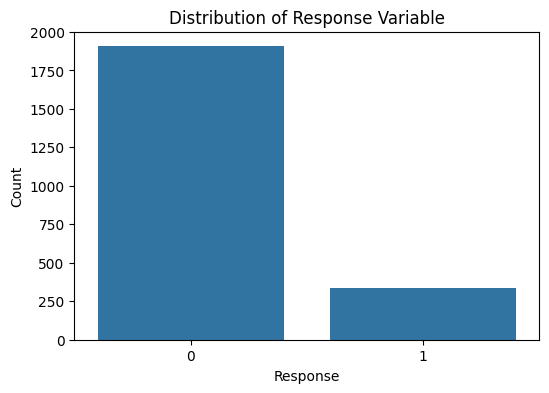

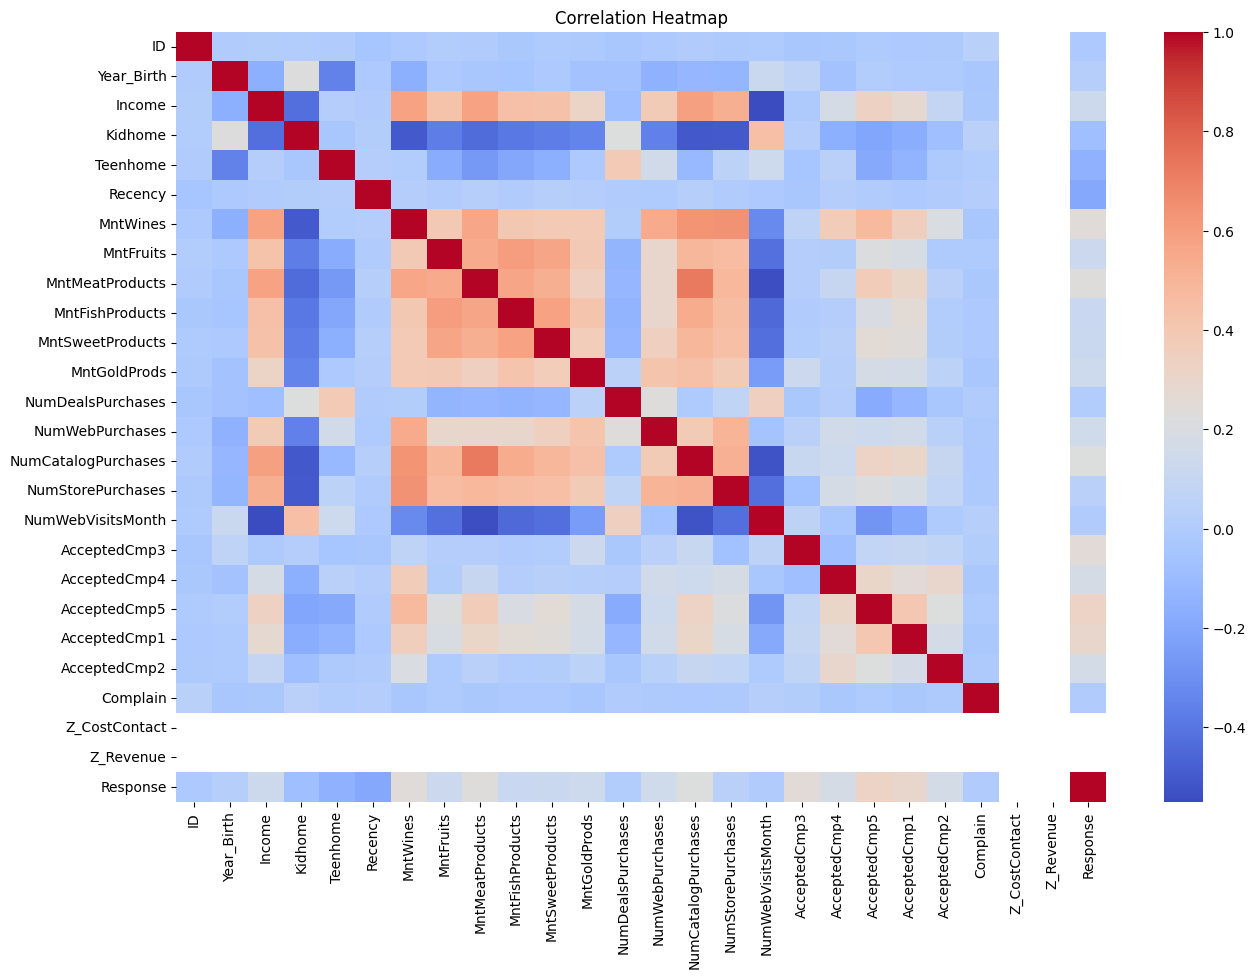


Feature Engineering Completed

New Features Created:
   Customer_Tenure  Age  Total_Children  Total_Spending  Total_Purchases
0              663   69               0            1617               22
1              113   72               2              27                4
2              312   61               0             776               20
3              139   42               1              53                6
4              161   45               1             422               14


In [2]:
# ==========================================================
# STEP 6: CHECK DUPLICATE RECORDS
# ==========================================================

duplicates = df.duplicated().sum()

print("\nNumber of Duplicate Records:", duplicates)

df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")

print(df.shape)


# ==========================================================
# STEP 7: TARGET VARIABLE DISTRIBUTION
# ==========================================================

print("\nResponse Variable Distribution:")

print(df["Response"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x="Response",
    data=df
)

plt.title(
    "Distribution of Response Variable"
)

plt.xlabel(
    "Response"
)

plt.ylabel(
    "Count"
)

plt.show()


# ==========================================================
# STEP 8: CORRELATION ANALYSIS
# ==========================================================

plt.figure(figsize=(15,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=False
)

plt.title(
    "Correlation Heatmap"
)

plt.show()


# ==========================================================
# STEP 9: FEATURE ENGINEERING
# ==========================================================

df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"]
)

latest_date = df["Dt_Customer"].max()

df["Customer_Tenure"] = (
    latest_date - df["Dt_Customer"]
).dt.days

df["Age"] = 2026 - df["Year_Birth"]

df = df[
    df["Age"] <= 100
]

df["Total_Children"] = (
    df["Kidhome"] +
    df["Teenhome"]
)

df["Total_Spending"] = (

    df["MntWines"]

    + df["MntFruits"]

    + df["MntMeatProducts"]

    + df["MntFishProducts"]

    + df["MntSweetProducts"]

    + df["MntGoldProds"]

)

df["Total_Purchases"] = (

    df["NumWebPurchases"]

    + df["NumCatalogPurchases"]

    + df["NumStorePurchases"]

)

print("\nFeature Engineering Completed")


# ==========================================================
# STEP 10: VIEW NEW FEATURES
# ==========================================================

new_features = [

    "Customer_Tenure",

    "Age",

    "Total_Children",

    "Total_Spending",

    "Total_Purchases"

]

print("\nNew Features Created:")

print(
    df[new_features].head()
)

In [3]:
# ==========================================================
# STEP 11: DROP IRRELEVANT COLUMNS
# ==========================================================

df.drop(

    columns=[

        "ID",

        "Dt_Customer",

        "Z_CostContact",

        "Z_Revenue"

    ],

    inplace=True

)

print("\nColumns Removed Successfully")


# ==========================================================
# STEP 12: ENCODE CATEGORICAL VARIABLES
# ==========================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Education"] = le.fit_transform(
    df["Education"]
)

df["Marital_Status"] = le.fit_transform(
    df["Marital_Status"]
)

print("\nCategorical Variables Encoded")


# ==========================================================
# STEP 13: DEFINE FEATURES AND TARGET
# ==========================================================

X = df.drop(

    "Response",

    axis=1

)

y = df["Response"]

print("\nFeature Matrix Shape:", X.shape)

print("Target Variable Shape:", y.shape)


# ==========================================================
# STEP 14: TRAIN TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\nTraining Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


# ==========================================================
# STEP 15: FEATURE SCALING
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("\nFeature Scaling Completed")

print(
    "Scaled Training Shape:",
    X_train_scaled.shape
)

print(
    "Scaled Testing Shape:",
    X_test_scaled.shape
)


# ==========================================================
# STEP 16: BUILD ANN FEATURE EXTRACTION MODEL
# Input → 500 → 100 → 1
# ==========================================================

from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

ann = Sequential([

    Input(
        shape=(X_train_scaled.shape[1],)
    ),

    Dense(

        500,

        activation='relu',

        name='hidden_layer_1'

    ),

    Dense(

        100,

        activation='relu',

        name='hidden_layer_2'

    ),

    Dense(

        1,

        activation='sigmoid',

        name='output_layer'

    )

])

print(
    "\nANN Architecture Created Successfully"
)

ann.summary()


Columns Removed Successfully

Categorical Variables Encoded

Feature Matrix Shape: (2237, 29)
Target Variable Shape: (2237,)

Training Data Shape: (1789, 29)
Testing Data Shape: (448, 29)

Feature Scaling Completed
Scaled Training Shape: (1789, 29)
Scaled Testing Shape: (448, 29)

ANN Architecture Created Successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 500)            │        15,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,201 (254.69 KB)

 Trainable params: 65,201 (254.69 KB)

 Non-trainable params: 0 (0.00 B)


ANN Model Compiled Successfully
Epoch 1/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7918 - loss: 0.5632 - val_accuracy: 0.8268 - val_loss: 0.4852
Epoch 2/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8567 - loss: 0.4315 - val_accuracy: 0.8268 - val_loss: 0.4287
Epoch 3/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8567 - loss: 0.3890 - val_accuracy: 0.8268 - val_loss: 0.3996
Epoch 4/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8574 - loss: 0.3644 - val_accuracy: 0.8296 - val_loss: 0.3781
Epoch 5/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8651 - loss: 0.3463 - val_accuracy: 0.8408 - val_loss: 0.3628
Epoch 6/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8679 - loss: 0.3319 - val_accuracy: 0.8436 - val_loss: 0.3489
Epoch 7/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8756 - loss: 0.3202 - val_accuracy: 0.8547 - val_loss: 0.3379
Epoch 8/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8791 

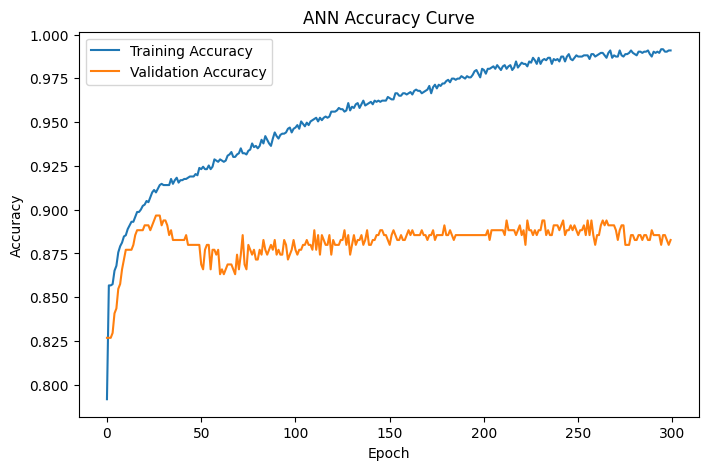

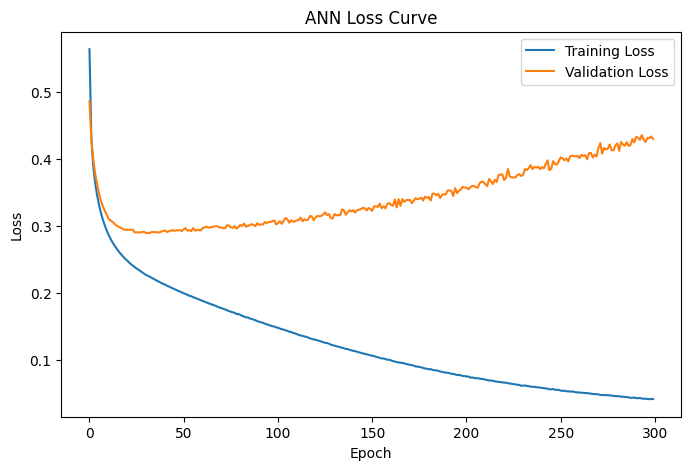

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Feature Extraction Completed
Training Feature Shape: (1789, 500)
Testing Feature Shape: (448, 500)

RBF SVM Model Trained Successfully


In [4]:
# ==========================================================
# STEP 17: COMPILE ANN MODEL
# ==========================================================

ann.compile(

    optimizer=SGD(
        learning_rate=0.01
    ),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

print("\nANN Model Compiled Successfully")


# ==========================================================
# STEP 18: TRAIN ANN MODEL
# ==========================================================

history = ann.fit(

    X_train_scaled,

    y_train,

    validation_split=0.20,

    epochs=300,

    batch_size=32,

    verbose=1

)

print("\nANN Training Completed")


# ==========================================================
# STEP 19: ANN ACCURACY CURVE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(

    history.history['accuracy'],

    label='Training Accuracy'

)

plt.plot(

    history.history['val_accuracy'],

    label='Validation Accuracy'

)

plt.title(
    'ANN Accuracy Curve'
)

plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'Accuracy'
)

plt.legend()

plt.show()


# ==========================================================
# STEP 20: ANN LOSS CURVE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(

    history.history['loss'],

    label='Training Loss'

)

plt.plot(

    history.history['val_loss'],

    label='Validation Loss'

)

plt.title(
    'ANN Loss Curve'
)

plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'Loss'
)

plt.legend()

plt.show()


# ==========================================================
# STEP 21: FEATURE EXTRACTION
# HIDDEN LAYER 1 (500 NEURONS)
# ==========================================================

from tensorflow.keras.models import Model

feature_model = Model(

    inputs=ann.inputs,

    outputs=ann.get_layer(
        "hidden_layer_1"
    ).output

)

X_train_features = feature_model.predict(
    X_train_scaled
)

X_test_features = feature_model.predict(
    X_test_scaled
)

print("\nFeature Extraction Completed")

print(
    "Training Feature Shape:",
    X_train_features.shape
)

print(
    "Testing Feature Shape:",
    X_test_features.shape
)


# ==========================================================
# STEP 22: BUILD RBF SVM CLASSIFIER
# ==========================================================

from sklearn.svm import SVC

svm_model = SVC(

    kernel='rbf',

    probability=True,

    random_state=42

)

svm_model.fit(

    X_train_features,

    y_train

)

print(
    "\nRBF SVM Model Trained Successfully"
)


Predictions Generated Successfully

MODEL PERFORMANCE
Accuracy     : 0.8772
Precision    : 0.7
Recall       : 0.3134
F1 Score     : 0.433
ROC-AUC      : 0.8869
Kappa Score  : 0.3752

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.89      0.98      0.93       381
           1       0.70      0.31      0.43        67

    accuracy                           0.88       448
   macro avg       0.79      0.64      0.68       448
weighted avg       0.86      0.88      0.86       448


METRICS TABLE

     Metric  Value
   Accuracy 0.8772
  Precision 0.7000
     Recall 0.3134
   F1 Score 0.4330
    ROC-AUC 0.8869
Kappa Score 0.3752


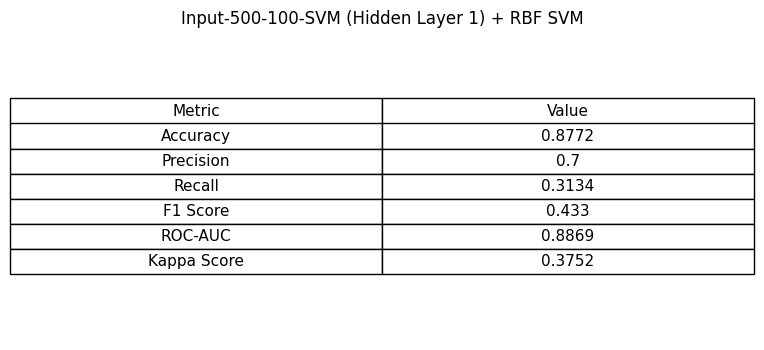

In [5]:
# ==========================================================
# STEP 23: MAKE PREDICTIONS
# ==========================================================

y_pred = svm_model.predict(
    X_test_features
)

y_prob = svm_model.predict_proba(
    X_test_features
)[:,1]

print("\nPredictions Generated Successfully")


# ==========================================================
# STEP 24: MODEL PERFORMANCE METRICS
# ==========================================================

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    cohen_kappa_score

)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_prob
)

kappa = cohen_kappa_score(
    y_test,
    y_pred
)


# ==========================================================
# STEP 25: DISPLAY METRICS
# ==========================================================

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("Accuracy     :", round(accuracy,4))
print("Precision    :", round(precision,4))
print("Recall       :", round(recall,4))
print("F1 Score     :", round(f1,4))
print("ROC-AUC      :", round(auc,4))
print("Kappa Score  :", round(kappa,4))


# ==========================================================
# STEP 26: CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import classification_report

print("\nCLASSIFICATION REPORT\n")

print(

    classification_report(

        y_test,

        y_pred

    )

)


# ==========================================================
# STEP 27: METRICS TABLE
# ==========================================================

metrics_table = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC",

        "Kappa Score"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1,

        auc,

        kappa

    ]

})

metrics_table["Value"] = metrics_table["Value"].round(4)

print("\nMETRICS TABLE\n")

print(
    metrics_table.to_string(index=False)
)


# ==========================================================
# STEP 28: VISUALIZE METRICS TABLE
# ==========================================================

plt.figure(figsize=(8,4))

plt.axis('off')

table = plt.table(

    cellText=metrics_table.values,

    colLabels=metrics_table.columns,

    cellLoc='center',

    loc='center'

)

table.auto_set_font_size(False)

table.set_fontsize(11)

table.scale(1.2,1.5)

plt.title(
    "Input-500-100-SVM (Hidden Layer 1) + RBF SVM"
)

plt.show()

Epoch = 50 | F1 Score = 0.4330
Epoch = 100 | F1 Score = 0.4330
Epoch = 150 | F1 Score = 0.4286
Epoch = 200 | F1 Score = 0.4286
Epoch = 250 | F1 Score = 0.4167
Epoch = 300 | F1 Score = 0.4167
Epoch = 350 | F1 Score = 0.3958
Epoch = 400 | F1 Score = 0.4124
Epoch = 450 | F1 Score = 0.4000
Epoch = 500 | F1 Score = 0.4082
Epoch = 600 | F1 Score = 0.4536
Epoch = 700 | F1 Score = 0.4124
Epoch = 800 | F1 Score = 0.4242
Epoch = 900 | F1 Score = 0.3958
Epoch = 1000 | F1 Score = 0.4124
Epoch = 1200 | F1 Score = 0.3958
Epoch = 1400 | F1 Score = 0.4286
Epoch = 1600 | F1 Score = 0.4356
Epoch = 1800 | F1 Score = 0.4124
Epoch = 2000 | F1 Score = 0.4286

Best Epoch = 600
Maximum F1 Score = 0.4536


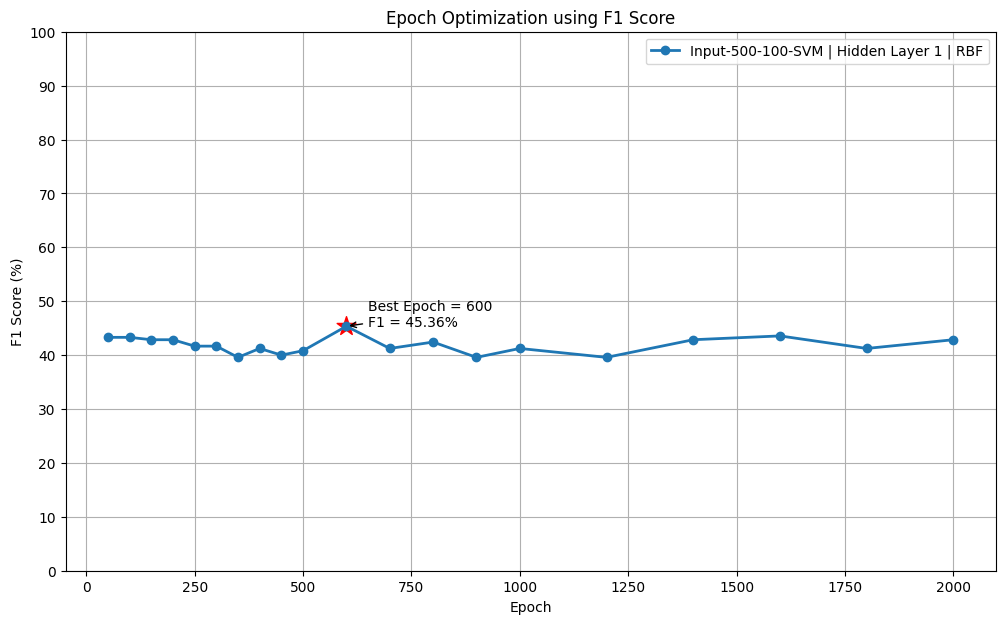

In [6]:
# ==========================================================
# EPOCH OPTIMIZATION GRAPH
# Architecture: Input-500-100-SVM
# Hidden Layer for Classification: 1 (500 Neurons)
# Kernel: RBF
# ==========================================================

from tensorflow.keras.models import Model
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

from sklearn.svm import SVC
from sklearn.metrics import f1_score

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# EPOCH SEARCH SPACE
# ==========================================================

epoch_list = [

    50,100,150,200,250,300,350,400,450,500,

    600,700,800,900,1000,1200,1400,1600,

    1800,2000

]

f1_scores = []

# ==========================================================
# TRAIN ANN + RBF SVM FOR EACH EPOCH
# ==========================================================

for epoch_value in epoch_list:

    ann = Sequential([

        Input(
            shape=(X_train_scaled.shape[1],)
        ),

        Dense(
            500,
            activation='relu',
            name='feature_layer'
        ),

        Dense(
            100,
            activation='relu'
        ),

        Dense(
            1,
            activation='sigmoid'
        )

    ])

    ann.compile(

        optimizer=SGD(
            learning_rate=0.01
        ),

        loss='binary_crossentropy',

        metrics=['accuracy']

    )

    ann.fit(

        X_train_scaled,

        y_train,

        epochs=epoch_value,

        batch_size=32,

        verbose=0

    )

    feature_model = Model(

        inputs=ann.inputs,

        outputs=ann.get_layer(
            "feature_layer"
        ).output

    )

    X_train_features = feature_model.predict(

        X_train_scaled,

        verbose=0

    )

    X_test_features = feature_model.predict(

        X_test_scaled,

        verbose=0

    )

    svm_model = SVC(

        kernel='rbf',

        C=1,

        gamma='scale',

        probability=True,

        random_state=42

    )

    svm_model.fit(

        X_train_features,

        y_train

    )

    y_pred = svm_model.predict(

        X_test_features

    )

    f1 = f1_score(

        y_test,

        y_pred,

        zero_division=0

    )

    f1_scores.append(

        f1

    )

    print(

        f"Epoch = {epoch_value} | F1 Score = {f1:.4f}"

    )

# ==========================================================
# FIND OPTIMUM EPOCH
# ==========================================================

best_index = np.argmax(

    f1_scores

)

best_epoch = epoch_list[best_index]

best_f1 = f1_scores[best_index]

print(

    f"\nBest Epoch = {best_epoch}"

)

print(

    f"Maximum F1 Score = {best_f1:.4f}"

)

# ==========================================================
# PLOT GRAPH
# ==========================================================

plt.figure(

    figsize=(12,7)

)

plt.plot(

    epoch_list,

    np.array(f1_scores) * 100,

    marker='o',

    linewidth=2,

    label='Input-500-100-SVM | Hidden Layer 1 | RBF'

)

plt.scatter(

    best_epoch,

    best_f1 * 100,

    s=200,

    marker='*',

    color='red'

)

plt.annotate(

    f'Best Epoch = {best_epoch}\nF1 = {best_f1*100:.2f}%',

    xy=(best_epoch, best_f1 * 100),

    xytext=(best_epoch + 50, best_f1 * 100),

    arrowprops=dict(
        arrowstyle='->'
    )

)

plt.xlabel(

    'Epoch'

)

plt.ylabel(

    'F1 Score (%)'

)

plt.title(

    'Epoch Optimization using F1 Score'

)

plt.ylim(

    0,

    100

)

plt.yticks(

    np.arange(

        0,

        101,

        10

    )

)

plt.grid(

    True

)

plt.legend()

plt.show()